# Demo: phân loại chữ số viết tay bằng mô hình **pre-trained** (transfer learning)

Ở notebook `mnist.ipynb`, ta huấn luyện một CNN **từ đầu** (3.658 tham số, 30 epoch).
Lần này ta làm theo cách phổ biến trong thực tế: **tái sử dụng một mô hình đã được
huấn luyện sẵn** trên bộ dữ liệu khổng lồ, thay vì học lại từ con số 0.

**Ý tưởng — Transfer learning (học chuyển giao).**
- Lấy `ResNet18` đã huấn luyện trên **ImageNet** (1,2 triệu ảnh, 1000 lớp).
- **Đông cứng** (freeze) toàn bộ phần xương sống → dùng nó như **bộ trích đặc trưng**:
  mỗi ảnh → vector 512 chiều mô tả nội dung.
- Chỉ huấn luyện **một tầng tuyến tính nhỏ** `Linear(512 → 10)` trên các đặc trưng đó.

| | Mô hình | Vai trò | Tham số |
|---|---|---|--:|
| 🧊 **Đông cứng** | ResNet18 (ImageNet) | trích đặc trưng, *không* huấn luyện | ~11,2 triệu |
| 🔥 **Huấn luyện** | `Linear(512→10)` | đầu phân loại | 5.130 |

Nhờ đặc trưng đã học từ hàng triệu ảnh, ta đạt độ chính xác tương đương CNN tự huấn
luyện nhưng **chỉ phải học một tầng tí hon** — và trích đặc trưng chỉ mất vài giây.

> Bộ trọng số ResNet18 (~45 MB) được torchvision tự tải về và lưu vào cache ở lần chạy
> đầu (`~/.cache/torch/hub/checkpoints`); các lần sau chạy hoàn toàn offline.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Dữ liệu

Vẫn là tập `digits` 8×8 quen thuộc (offline) như notebook trước, để dễ so sánh.

In [2]:
digits = load_digits()
X = digits.images.astype("float32") / 16.0      # (1797, 8, 8) -> [0, 1]
y = digits.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_train_t = torch.tensor(y_train)
y_test_t = torch.tensor(y_test)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1437, 8, 8) | Test: (360, 8, 8)


## 2. Nạp mô hình pre-trained và đông cứng

`backbone.fc = nn.Identity()` bỏ tầng phân loại 1000 lớp của ImageNet, biến ResNet18
thành hàm trả về **vector đặc trưng 512 chiều**. Đặt `requires_grad = False` cho mọi
tham số để khẳng định: ta **không** huấn luyện phần này.

In [3]:
weights = ResNet18_Weights.IMAGENET1K_V1     # tải về & cache ở lần đầu, sau đó offline
backbone = resnet18(weights=weights)
backbone.fc = nn.Identity()                  # bỏ đầu 1000 lớp -> xuất 512 đặc trưng
backbone.eval()                              # eval: BatchNorm dùng thống kê đã học
for p in backbone.parameters():
    p.requires_grad = False                  # đông cứng toàn bộ xương sống

n_frozen = sum(p.numel() for p in backbone.parameters())
print(f"ResNet18 (đông cứng): {n_frozen:,} tham số — KHÔNG huấn luyện")

ResNet18 (đông cứng): 11,176,512 tham số — KHÔNG huấn luyện


## 3. Tiền xử lý + trích đặc trưng

ResNet kỳ vọng ảnh **RGB cỡ ~224** chuẩn hóa theo thống kê ImageNet, trong khi digits
là ảnh **xám 8×8**. Ta phóng to lên 96×96 (đủ để ResNet hoạt động tốt, vẫn nhanh),
**nhân ảnh xám thành 3 kênh**, rồi chuẩn hóa theo mean/std của ImageNet.

Đặc trưng được tính **một lần** rồi lưu lại — vì xương sống đông cứng, không cần tính
lại mỗi epoch.

In [4]:
IMG_SIZE = 96
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)   # mean/std ImageNet
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def extract_features(images_8x8):
    '''(N, 8, 8) ảnh xám -> (N, 512) đặc trưng từ ResNet18 đông cứng.'''
    x = torch.tensor(images_8x8).unsqueeze(1)                          # (N, 1, 8, 8)
    x = F.interpolate(x, size=IMG_SIZE, mode="bilinear", align_corners=False)
    x = x.repeat(1, 3, 1, 1)                                           # xám -> RGB
    x = (x - mean) / std                                              # chuẩn hóa ImageNet
    feats = []
    with torch.no_grad():                                            # không cần gradient
        for i in range(0, len(x), 128):                              # chạy theo batch
            feats.append(backbone(x[i:i + 128]))
    return torch.cat(feats)

t0 = time.time()
F_train = extract_features(X_train)
F_test = extract_features(X_test)
print(f"Trích đặc trưng xong trong {time.time() - t0:.1f}s")
print("Đặc trưng train:", tuple(F_train.shape), "| test:", tuple(F_test.shape))

Trích đặc trưng xong trong 6.2s
Đặc trưng train: (1437, 512) | test: (360, 512)


## 4. Huấn luyện đầu phân loại (chỉ 1 tầng tuyến tính)

Chỉ tầng `Linear(512 → 10)` được học. Vì đặc trưng đã tính sẵn nên 30 epoch chạy
gần như tức thì.

In [5]:
EPOCHS = 30
BATCH_SIZE = 64

head = nn.Linear(512, 10)                    # đầu phân loại: 512*10 + 10 = 5.130 tham số
n_trained = sum(p.numel() for p in head.parameters())

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
gen = torch.Generator().manual_seed(SEED)
n_batches = (len(F_train) + BATCH_SIZE - 1) // BATCH_SIZE

for epoch in range(EPOCHS):
    head.train()
    perm = torch.randperm(len(F_train), generator=gen)
    running = 0.0
    for i in range(0, len(F_train), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        loss = loss_fn(head(F_train[idx]), y_train_t[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:2d}/{EPOCHS} - loss: {running / n_batches:.4f}")

print(f"\nĐầu phân loại được huấn luyện: {n_trained:,} tham số")

Epoch  1/30 - loss: 1.7465
Epoch  5/30 - loss: 0.4838
Epoch 10/30 - loss: 0.2812
Epoch 15/30 - loss: 0.1967
Epoch 20/30 - loss: 0.1544
Epoch 25/30 - loss: 0.1221
Epoch 30/30 - loss: 0.1036

Đầu phân loại được huấn luyện: 5,130 tham số


## 5. Đánh giá

In [6]:
head.eval()
with torch.no_grad():
    preds = head(F_test).argmax(dim=1)
    accuracy = (preds == y_test_t).float().mean().item()
print(f"Độ chính xác trên tập kiểm tra: {100 * accuracy:.1f}%")

Độ chính xác trên tập kiểm tra: 95.8%


In [7]:
acc_str = f"{100 * accuracy:.1f}".replace(".", ",")
trained_str = f"{n_trained:,}".replace(",", ".")
frozen_str = f"{n_frozen:,}".replace(",", ".")

cards = [
    ("#2e7d52", f"{acc_str}%",   "Độ chính xác trên tập kiểm tra"),
    ("#1b3a4b", trained_str,     "Tham số được huấn luyện (đầu phân loại)"),
    ("#d98324", frozen_str,      "Tham số pre-trained (đông cứng)"),
]
html = '<div style="display:flex;gap:16px;font-family:Georgia,serif;margin:8px 0;">'
for color, value, label in cards:
    html += (
        f'<div style="flex:1;background:#eef3ef;border-left:6px solid {color};'
        f'padding:18px 22px;border-radius:4px;">'
        f'<div style="font-size:38px;font-weight:700;color:{color};line-height:1;">{value}</div>'
        f'<div style="color:#3a3a3a;margin-top:10px;font-size:15px;">{label}</div></div>'
    )
html += "</div>"
display(HTML(html))

## 6. Trực quan hóa dự đoán

10 mẫu đầu trong tập kiểm tra cùng nhãn dự đoán
(**xanh = đúng**, **đỏ = sai**).

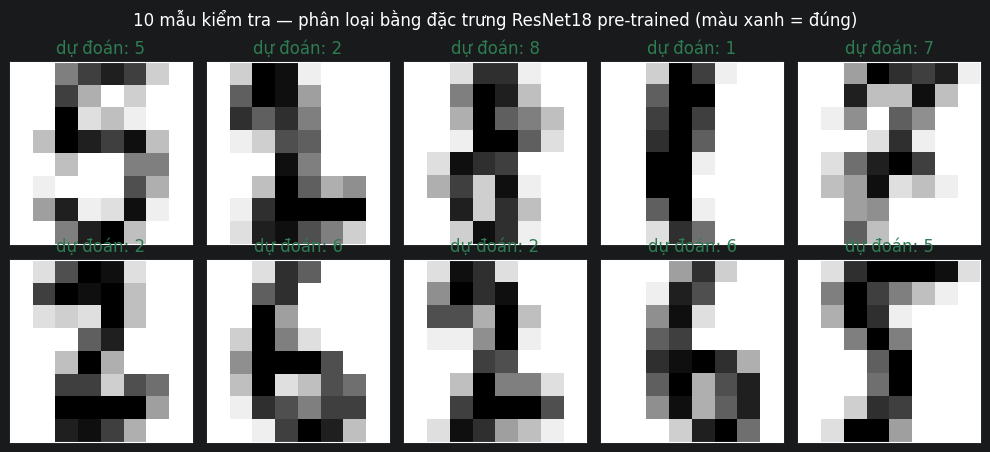

In [8]:
n_show = 10
fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))
for ax, i in zip(axes.ravel(), range(n_show)):
    pred = preds[i].item()
    true = y_test_t[i].item()
    color = "#2e7d52" if pred == true else "#c0392b"
    ax.imshow(X_test[i], cmap="gray_r")
    ax.set_title(f"dự đoán: {pred}", color=color, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("10 mẫu kiểm tra — phân loại bằng đặc trưng ResNet18 pre-trained "
             "(màu xanh = đúng)", fontsize=12)
plt.tight_layout()
plt.show()